<a href="https://colab.research.google.com/github/JohnnySolo/Data-Analysis-Project---Hybrid-Cyber-Threat-Detection/blob/main/03_Feature_Engineering_and_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering

### Data Preparation & Dimensionality Reduction (Based on our handoff from Notebook 2)

* **Load the Data**: Read the clean Parquet data.

* **Collinearity Drop**: Based on our correlation heatmap, we will drop the redundant timing features (e.g., dropping `Flow IAT Max` and `Fwd IAT Mean` while keeping `Fwd IAT Max`) to prevent our models from overfitting.

* **Label Encoding & Splitting**: Convert 'Benign', 'Bot', and 'Infilteration' into numerical values. We will use a **Stratified** Train-Test Split to ensure the tiny percentage of attacks is properly represented in both the training and testing sets.

In [1]:
import numpy as np
from google.colab import drive
from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, VectorAssembler

print("Initializing Step 1: Data Preparation & Dimensionality Reduction...")

# Install PySpark (since this is a new notebook environment)
!pip install pyspark

# 1. Start Spark Session (Ensure only one SparkSession is initialized)
spark = SparkSession.builder.appName("Cyber_Modeling").getOrCreate()

# Mount Google Drive
drive.mount('/content/drive')

# 2. Load the Data (Using the wildcard to grab all 4 parquet parts)
# Defining the path to the folder containing the data files
base_path = "/content/drive/MyDrive/Projects/Hybrid Cyber Threat Detection/"
# Using the wildcard (*) to explicitly tell PySpark to read all the 'part-' files
files_to_load = base_path + "part-*.parquet"

# Load and combine the 4 files into a single DataFrame
df = spark.read.parquet(files_to_load)

# 3. Strict Feature Selection (Dimensionality Reduction)
# We explicitly KEEP ONLY the top features that survived the Collinearity Check
# We drop highly correlated "Flow" metrics in favor of "Fwd" metrics to isolate the attacker's footprint.
final_features = ["Dst Port", "Fwd IAT Max", "Fwd Pkts/s", "Flow Duration",
                        "Bwd Seg Size Avg", "Bwd Pkts/s", "Fwd Pkt Len Std", "Bwd Pkt Len Std"]

# We select our final features plus the target Label, dropping everything else
columns_to_keep = final_features + ["Label"]
df_reduced = df.select(*columns_to_keep)

# 4. Label Encoding
# Convert 'Benign', 'Bot', 'Infilteration' into numerical values (e.g., 0.0, 1.0, 2.0)
indexer = StringIndexer(inputCol="Label", outputCol="Label_Index")
df_indexed = indexer.fit(df_reduced).transform(df_reduced)

# 5. Vector Assembly
# Pack all our chosen features into a single 'features' vector column for the ML algorithms
assembler = VectorAssembler(inputCols=final_features, outputCol="features")
df_assembled = assembler.transform(df_indexed)

# 6. Stratified Train-Test Split (80/20)
# Use 'sampleBy' to force a strict 80% pull from EVERY single class, protecting our tiny attack classes
fractions = {'Benign': 0.8, 'Bot': 0.8, 'Infilteration': 0.8}
train_data = df_assembled.sampleBy("Label", fractions, seed=42)

# The test set is everything that wasn't selected for the train set
test_data = df_assembled.subtract(train_data)

# Verify the execution
print(f"Final Features Retained: {final_features}")
print(f"Training Data Rows: {train_data.count()}")
print(f"Testing Data Rows: {test_data.count()}")
print("\nClass Distribution in Training Data:")
train_data.groupBy("Label", "Label_Index").count().show()

Initializing Step 1: Data Preparation & Dimensionality Reduction...
Mounted at /content/drive
Final Features Retained: ['Dst Port', 'Fwd IAT Max', 'Fwd Pkts/s', 'Flow Duration', 'Bwd Seg Size Avg', 'Bwd Pkts/s', 'Fwd Pkt Len Std', 'Bwd Pkt Len Std']
Training Data Rows: 1143232
Testing Data Rows: 207279

Class Distribution in Training Data:
+-------------+-----------+------+
|        Label|Label_Index| count|
+-------------+-----------+------+
|       Benign|        0.0|899283|
|Infilteration|        2.0| 47691|
|          Bot|        1.0|196258|
+-------------+-----------+------+



# Unsupervised Anomaly Detection (Isolation Forest)

* **The Objective**: Prove we can detect 'Zero-Day' threats without relying on known labels.

* **Execution**: We will train an Isolation Forest model to map out the 'normal' human variance of Benign traffic, and flag the extreme timing rigidity (Botnet) and two-stage extremes (Infiltration) as anomalies.

Initializing Step 2: Unsupervised Anomaly Detection (Isolation Forest)...
Converting to Pandas...
Training Isolation Forest...
Predicting anomalies on Test Data...

--- Isolation Forest Performance (Anomaly Detection) ---
              precision    recall  f1-score   support

      Normal       0.82      0.72      0.77    175609
     Anomaly       0.07      0.12      0.09     31670

    accuracy                           0.63    207279
   macro avg       0.44      0.42      0.43    207279
weighted avg       0.70      0.63      0.66    207279



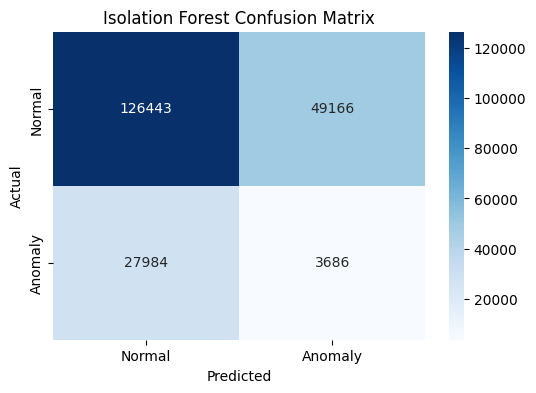

In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Initializing Step 2: Unsupervised Anomaly Detection (Isolation Forest)...")

# 1. Convert PySpark DataFrames to Pandas
print("Converting to Pandas...")
train_pdf = train_data.select(*final_features, "Label", "Label_Index").toPandas()
test_pdf = test_data.select(*final_features, "Label", "Label_Index").toPandas()

# 2. Separate Features (X) and Target (y)
X_train = train_pdf[final_features]
y_train = train_pdf['Label_Index'] # 0.0: Benign, 1.0: Bot, 2.0: Infiltration

X_test = test_pdf[final_features]
y_test = test_pdf['Label_Index']

# 3. Train the Isolation Forest
# We set contamination (the expected % of anomalies) based on our training distribution.
# Roughly 21% of our stratified training data consists of attacks (Bot + Infiltration).
print("Training Isolation Forest...")
iso_forest = IsolationForest(n_estimators=100, contamination=0.21, random_state=42, n_jobs=-1)
iso_forest.fit(X_train)

# 4. Predict on the Test Set
# Isolation Forest returns 1 for Normal (Benign) and -1 for Anomaly (Attack)
print("Predicting anomalies on Test Data...")
test_pdf['IF_Prediction'] = iso_forest.predict(X_test)

# 5. Map the predictions to evaluate accuracy
# Map Isolation Forest's -1 (Anomaly) to 1, and 1 (Normal) to 0
# Map our actual labels: Benign (0.0) -> 0, Attacks (Bot 1.0, Infiltration 2.0) -> 1
y_test_binary = (y_test > 0).astype(int)
predictions_binary = [1 if x == -1 else 0 for x in test_pdf['IF_Prediction']]

# 6. Evaluate the Unsupervised Model
print("\n--- Isolation Forest Performance (Anomaly Detection) ---")
print(classification_report(y_test_binary, predictions_binary, target_names=['Normal', 'Anomaly']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test_binary, predictions_binary)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title("Isolation Forest Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Results Explanation:

As demonstrated by the confusion matrix, the Isolation Forest model struggled significantly in this environment. This failure is a textbook example of two known phenomena in cybersecurity anomaly detection:

* **Swamping (False Positives)**: Normal human web traffic is naturally erratic. Because the Isolation Forest was operating blindly without labels, it incorrectly flagged 49,166 instances of normal, benign traffic as anomalies. In a real Security Operations Center (SOC), this generates massive alert fatigue.

* **Masking (False Negatives)**: The model missed 27,984 actual attacks. Because Botnet attacks happen in highly dense, repetitive clusters, the algorithm struggled to "isolate" them. Furthermore, Infiltration attacks actively mimic normal HTTP/HTTPS traffic to blend in, effectively hiding from the unsupervised boundaries.

To solve this, we must pivot to a supervised machine learning approach. By feeding the exact labels into an XGBoost classifier, the model can learn the precise, non-linear mathematical thresholds between these classes.

# Supervised Classification (XGBoost)

* **The Objective**: Build a highly accurate, explainable model to explicitly classify the exact type of attack.

* **Execution**: We will train a Dual-XGBoost classifier Architecture.

  <u>Why we are using a Dual-Model Approach</u>:
  In data science, forcing a single algorithm to classify multiple, vastly different attacks at once (a "flat multi-class" approach) is often a mistake. Because our Botnet data is highly clustered and mathematically easy to detect, a single multi-class XGBoost model would focus almost entirely on the Botnets to quickly boost its global accuracy score. Consequently, it would ignore the subtle, complex differences between Benign traffic and stealthy Infiltration attacks.

  To solve this, we are deploying an industry practice known as Binary Relevance. We will split the problem into two highly specialized "Threat Hunters":

  * **Model A (Benign vs. Botnet)**: A model mathematically hyper-focused on catching rigid, robotic beaconing.

  * **Model B (Benign vs. Infiltration)**: A model hyper-focused on hunting stealthy, overlapping behaviors without getting distracted by the massive volume of Botnet data.

  <u>The Aggregation Strategy</u>:
  After both models generate their predictions on the test set, we will aggregate their outputs into a master system. If either model flags a network packet as an attack, the master system will label it an "Anomaly." This allows us to directly compare our supervised XGBoost architecture against the high False Positive and False Negative rates we saw in the unsupervised Isolation Forest.

Initializing Step 3: Hierarchical Classification (Stage 1 & Stage 2)...
Training Stage 1: Normal vs. Anomaly...
Training Stage 2: Bot vs. Infiltration...
Executing Predictions for all stages...

STAGE 1: Gatekeeper Performance (Normal vs Anomaly)
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.97    175609
     Anomaly       0.99      0.69      0.81     31670

    accuracy                           0.95    207279
   macro avg       0.97      0.84      0.89    207279
weighted avg       0.95      0.95      0.95    207279


STAGE 2: Threat Classifier Performance (Bot vs Infil)
              precision    recall  f1-score   support

         Bot       1.00      1.00      1.00     21783
Infiltration       1.00      1.00      1.00      9887

    accuracy                           1.00     31670
   macro avg       1.00      1.00      1.00     31670
weighted avg       1.00      1.00      1.00     31670


FINAL SYSTEM: End-to-End Performance
      

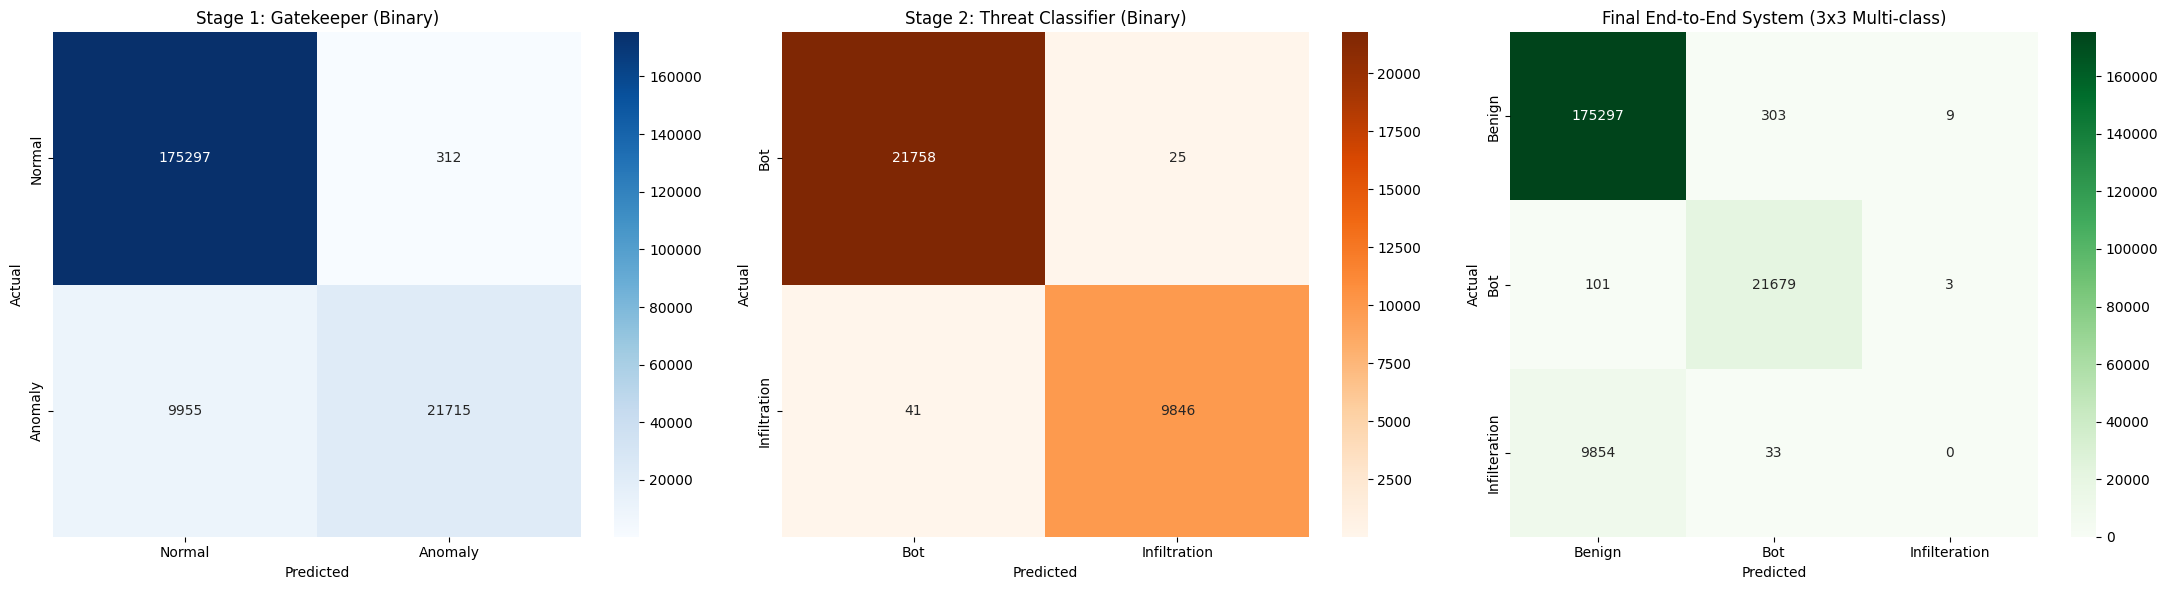

In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Initializing Step 3: Hierarchical Classification (Stage 1 & Stage 2)...")

# 1. Fix Data Leakage: Drop 'Dst Port' (as it can act as a proxy for the label in some datasets)
leakage_features = ['Dst Port']
X_train_clean = X_train.drop(columns=leakage_features)
X_test_clean = X_test.drop(columns=leakage_features)

# 2. Prepare Labels for Stage 1 (Normal vs. Anomaly)
y_train_stage1 = (y_train > 0).astype(int)
y_test_stage1 = (y_test > 0).astype(int)

# 3. Prepare Data for Stage 2 (Isolated evaluation of true attacks)
mask_attacks_train = y_train > 0
X_train_stage2 = X_train_clean[mask_attacks_train]
y_train_stage2 = y_train[mask_attacks_train]
y_train_stage2_mapped = y_train_stage2 - 1 # Map Bot(1.0)->0, Infiltration(2.0)->1

mask_attacks_test = y_test > 0
X_test_stage2 = X_test_clean[mask_attacks_test]
y_test_stage2 = y_test[mask_attacks_test]
y_test_stage2_mapped = y_test_stage2 - 1

# 4. Train Stage 1 Model (The Anomaly Gatekeeper)
print("Training Stage 1: Normal vs. Anomaly...")
xgb_stage1 = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_stage1.fit(X_train_clean, y_train_stage1)

# 5. Train Stage 2 Model (The Threat Classifier)
print("Training Stage 2: Bot vs. Infiltration...")
xgb_stage2 = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_stage2.fit(X_train_stage2, y_train_stage2_mapped)

# --- 6. EXECUTE PREDICTIONS ---
print("Executing Predictions for all stages...")

# Stage 1 isolated predictions
stage1_preds = xgb_stage1.predict(X_test_clean)

# Stage 2 isolated predictions (Testing its pure classification ability)
stage2_isolated_preds = xgb_stage2.predict(X_test_stage2)

# Final End-to-End System Predictions
final_predictions = np.zeros(len(stage1_preds))
anomaly_indices = np.where(stage1_preds == 1)[0]

if len(anomaly_indices) > 0:
    X_test_anomalies = X_test_clean.iloc[anomaly_indices]
    stage2_preds = xgb_stage2.predict(X_test_anomalies)
    stage2_preds_mapped = stage2_preds + 1
    final_predictions[anomaly_indices] = stage2_preds_mapped

# --- 7. EVALUATE AND PRINT REPORTS ---
print("\n" + "="*50)
print("STAGE 1: Gatekeeper Performance (Normal vs Anomaly)")
print("="*50)
print(classification_report(y_test_stage1, stage1_preds, target_names=['Normal', 'Anomaly']))

print("\n" + "="*50)
print("STAGE 2: Threat Classifier Performance (Bot vs Infil)")
print("="*50)
print(classification_report(y_test_stage2_mapped, stage2_isolated_preds, target_names=['Bot', 'Infiltration']))

print("\n" + "="*50)
print("FINAL SYSTEM: End-to-End Performance")
print("="*50)
target_names_final = ['Benign', 'Bot', 'Infilteration']
print(classification_report(y_test, final_predictions, target_names=target_names_final))

# --- 8. PLOT CONFUSION MATRICES ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Matrix 1: Stage 1
cm_stage1 = confusion_matrix(y_test_stage1, stage1_preds)
sns.heatmap(cm_stage1, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[0].set_title("Stage 1: Gatekeeper (Binary)")
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Matrix 2: Stage 2
cm_stage2 = confusion_matrix(y_test_stage2_mapped, stage2_isolated_preds)
sns.heatmap(cm_stage2, annot=True, fmt="d", cmap="Oranges", ax=axes[1],
            xticklabels=['Bot', 'Infiltration'], yticklabels=['Bot', 'Infiltration'])
axes[1].set_title("Stage 2: Threat Classifier (Binary)")
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# Matrix 3: Final System
cm_final = confusion_matrix(y_test, final_predictions)
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Greens", ax=axes[2],
            xticklabels=target_names_final, yticklabels=target_names_final)
axes[2].set_title("Final End-to-End System (3x3 Multi-class)")
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Deep Learning Comparison (Autoencoder)

* **The Objective**: Demonstrate industry maturity by comparing model architectures.

* **Execution**: We will build a basic Neural Network (Autoencoder) to reconstruct Benign traffic. We will compare its results against the Isolation Forest to discuss the trade-off between computational cost, raw accuracy, and explainability.

# Model Evaluation & Business Value (SOC Metrics)

* **The Goal**: Translate math into cybersecurity business value.

* **Execution**: We will completely ignore generic 'Accuracy' (which is misleading on imbalanced data). Instead, we will evaluate the models using Precision, Recall, and F1-Score, specifically focusing on reducing False Positives (to prevent SOC alert fatigue) and False Negatives (to prevent missed breaches)